# Contributions
## Nicholas, Dylan, Kayla
**Note**
- Common functions were shared and used across all model implementations.
- Shared functions were reviewed and approved by members of the ML branch before being refactored for reusability.
- All members participated in results analysis.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Train set: (50000, 32, 32, 3)
Test set: (10000, 32, 32, 3)
Training set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Extracting HOG features...
Training Random Forest model...

===== MODEL PERFORMANCE =====
Training Accuracy:   1.0000
Validation Accuracy: 0.4248
Test Accuracy:       0.4297

Generalisation Gap: 0.5752

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    airplane       0.51      0.50      0.51      1000
  automobile       0.53      0.65      0.58      1000
        bird       0.33      0.25      0.28      1000
         cat       0.28      0.23      0.25      1000
        deer       0.34      0.37      0.35      1000
         dog       0.34      0.37      0.35      1000
        frog       0.44      0.55      0.48      1000
       horse       0.48      0.41      0.44      1000
        ship       0.48      0.49      0.49      1000
       truck       0.51      0.49      0.

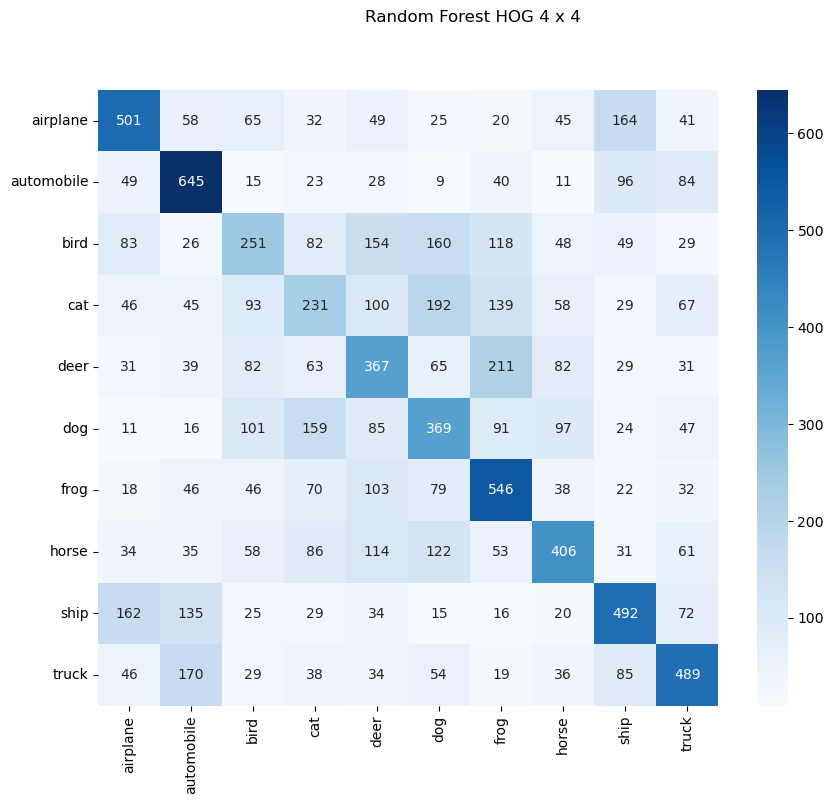

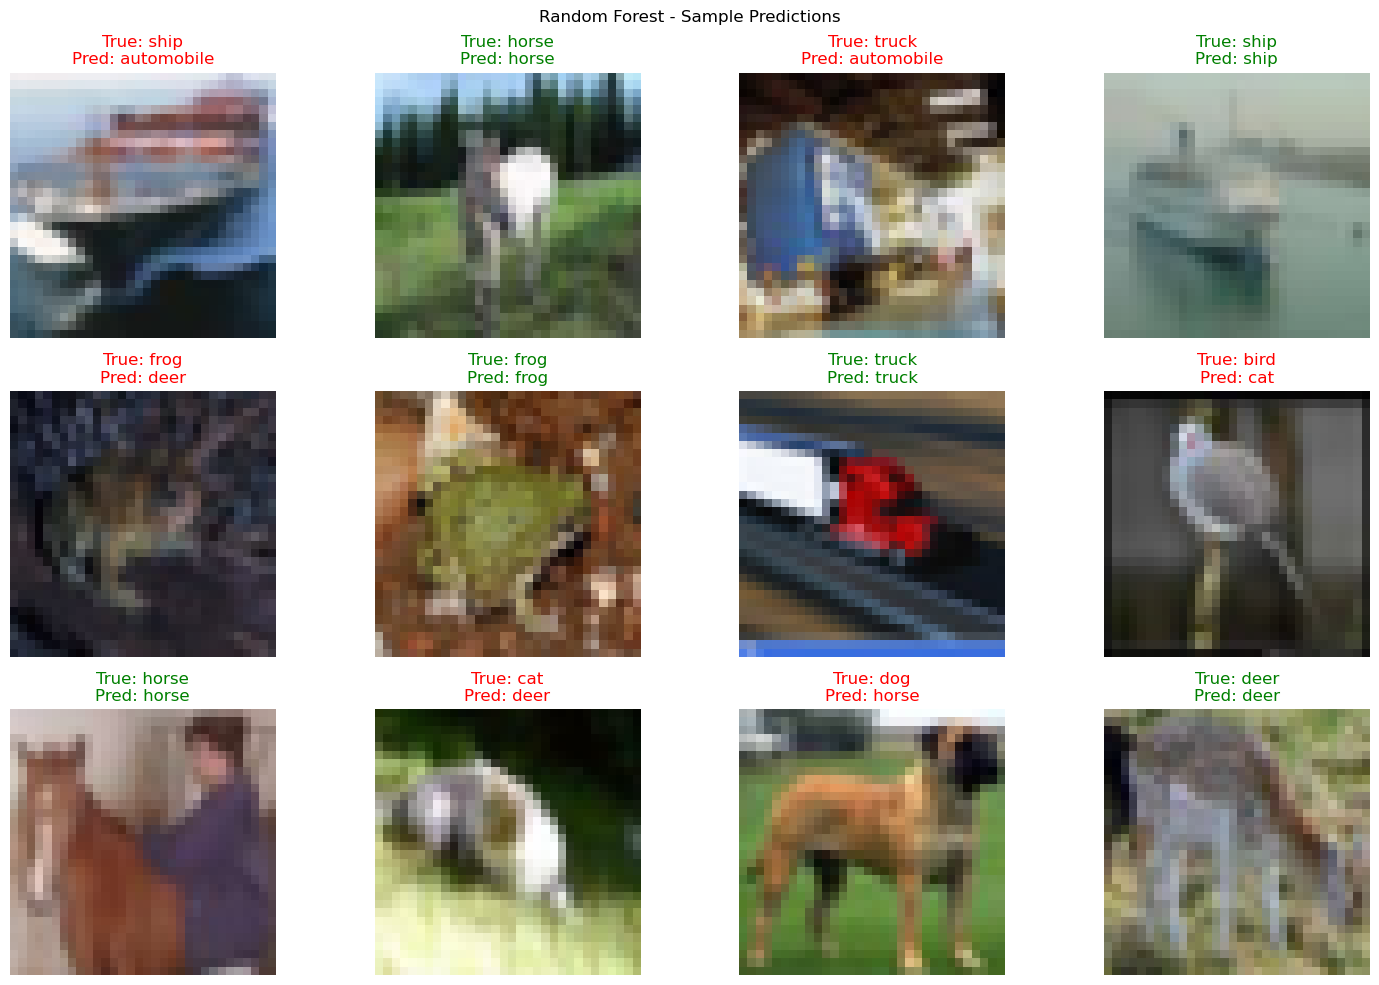

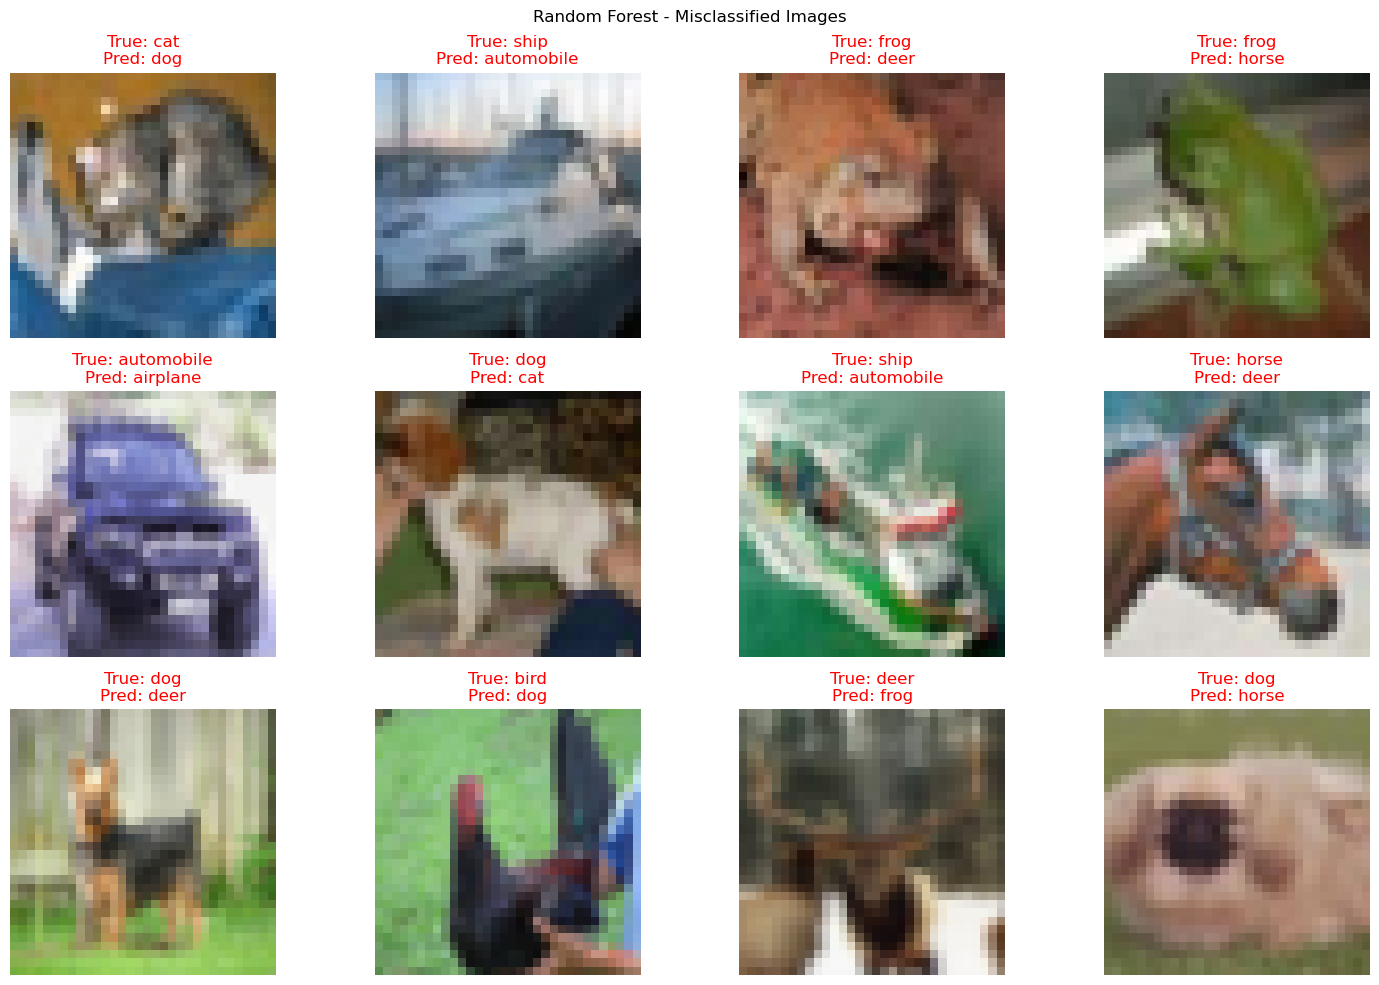

In [5]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10

from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# Load CIFAT-10 dataset
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Flatten labels
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print("Train set:", X_train_full.shape)
print("Test set:", X_test.shape)


# Train and validation split, 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

# Feature extraction
# HOG converts images to gray scale, then coverts images into vectors (32 x 32 x 3) -> (32 x 32)
# the normalisation is performed to remove noise
def extract_hog(images):
    features = []

    for img in images:

        # Convert RGB to gray scale
        gray = rgb2gray(img)

        # Extract Histogram of Oriented Gradients (HOG)
        hog_feat = hog(
            gray,
            orientations=9,        # the number of gradients to use (0, 20, 40 ,60, 80, 100, 120, 140, 160)
            pixels_per_cell=(4,4), # divides images into cells of pixels (4 x 4)
            cells_per_block=(2,2), # group cells into blocks of 2 x 2 cells (8 x 8 pixels)
            block_norm='L2-Hys'    # normalisation method (removes noise)
        )

        features.append(hog_feat)

    return np.array(features)

print("Extracting HOG features...")

# Convert images into feature vectors
X_train_hog = extract_hog(X_train)
X_val_hog = extract_hog(X_val)
X_test_hog = extract_hog(X_test)

# Defined the model (Random Forest)
# Random forest uses muiltiple layers of decision tree's to make classifications
# Different decision tree's are trained on slightly different random subsets of the training data
model = RandomForestClassifier(
    n_estimators=100,   # number of trees in the forest
    random_state=42,    # ensures reproducibility
    n_jobs=-1           # uses all CPU cores for speed
)

#Train the model
print("Training Random Forest model...")
model.fit(X_train_hog, y_train)

# Make Predictions
train_pred = model.predict(X_train_hog)
val_pred = model.predict(X_val_hog)
test_pred = model.predict(X_test_hog)

# Evaluate accuracy
train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\n===== MODEL PERFORMANCE =====")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

print(f"\nGeneralisation Gap: {train_acc - val_acc:.4f}")

# Generate classification report
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    test_pred,
    target_names=class_names
))

# Generate confusion matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(10, 8))
plt.suptitle("Random Forest HOG 4 x 4")
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)



# Shows model predictions on random test images
num_samples = 12

indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])

    true_label = class_names[y_test[idx]]
    pred_label = class_names[test_pred[idx]]

    # green = correct, red = incorrect
    color = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.suptitle("Random Forest - Sample Predictions")
plt.tight_layout()
plt.show()

# Show missclassified images
incorrect = np.where(test_pred != y_test)[0]

num_errors = min(12, len(incorrect))

plt.figure(figsize=(15, 10))

# Loop through all
for i in range(num_errors):

    idx = incorrect[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])

    true_label = class_names[y_test[idx]]
    pred_label = class_names[test_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}", color="red")
    plt.axis("off")

plt.suptitle("Random Forest - Misclassified Images")
plt.tight_layout()
plt.show()

Loaded CIFAR-10: training=50000, test=10000, classes=10
Feature shape after grayscale conversion: 1024 features per image
Validation set size: 10000
GridSearchCV tuning size: 12000
Validation model training size: 40000
Final refit training size: 50000

Tuning Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Final Logistic Regression Results
Best parameters: {'C': 0.01}
Best cross-validation accuracy: 0.2953
Validation accuracy: 0.2990
Test accuracy: 0.3110
Test macro precision: 0.3043
Test macro recall: 0.3110
Test macro F1-score: 0.3055
Tuning time: 666.79 seconds
Final training time: 92.01 seconds
Test prediction time: 0.07 seconds

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    airplane       0.31      0.34      0.32      1000
  automobile       0.36      0.40      0.38      1000
        bird       0.26      0.21      0.23      1000
         cat       0.23      0.16      0.19      1000
        deer      

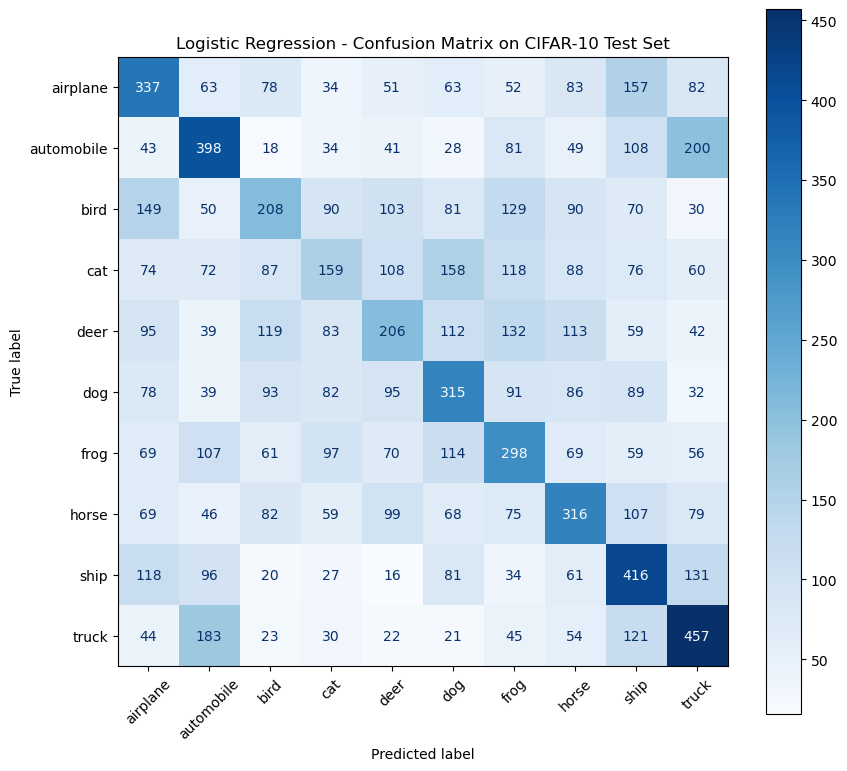

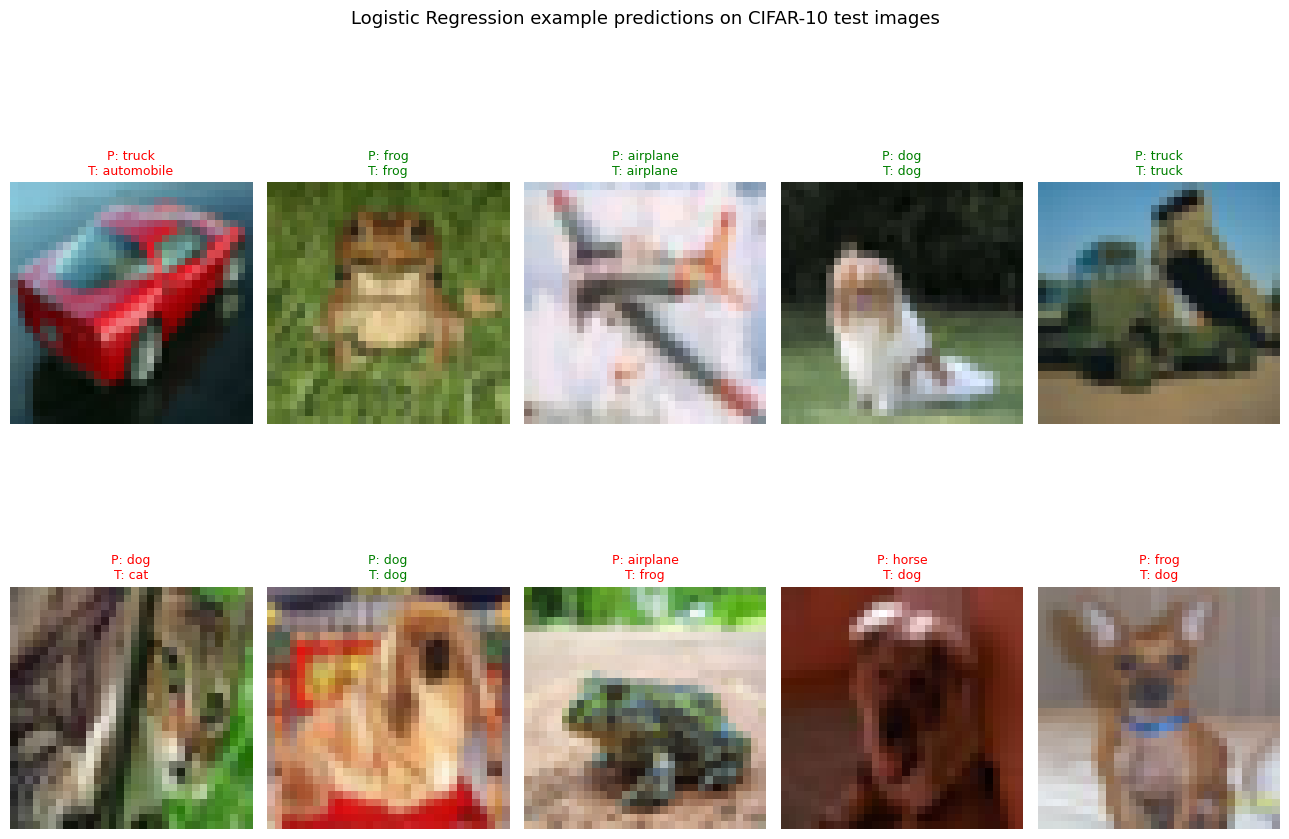

In [13]:
# Dylan Nguyen
# Cell 2 - Logistic Regression - Self Assessment score 1

import argparse
import pickle
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, train_test_split


DEFAULT_DATA_DIR = Path("cifar-10-batches-py")
RANDOM_STATE = 42


# Load CIFAR-10 pickle files.
def load_pickle(path):
    with path.open("rb") as file:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return pickle.load(file, encoding="latin1")


# Load the official CIFAR-10 training and test split.
def load_cifar10(data_dir):
    train_batches = []
    train_labels = []

    for batch_number in range(1, 6):
        batch = load_pickle(data_dir / f"data_batch_{batch_number}")
        train_batches.append(batch["data"])
        train_labels.extend(batch["labels"])

    test_batch = load_pickle(data_dir / "test_batch")
    metadata = load_pickle(data_dir / "batches.meta")

    x_train = np.vstack(train_batches).astype(np.float32)
    y_train = np.array(train_labels, dtype=np.int64)
    x_test = test_batch["data"].astype(np.float32)
    y_test = np.array(test_batch["labels"], dtype=np.int64)
    class_names = metadata["label_names"]

    return x_train, y_train, x_test, y_test, class_names


# Feature engineering: convert RGB images into scaled grayscale pixel features.
def rgb_flat_to_grayscale_features(x):
    images = x.reshape(-1, 3, 32, 32)
    red = images[:, 0]
    green = images[:, 1]
    blue = images[:, 2]

    grayscale = 0.299 * red + 0.587 * green + 0.114 * blue
    grayscale = grayscale / 255.0

    return grayscale.reshape(len(x), -1)


# Select a stratified subset when a smaller sample is requested.
def limit_stratified_sample(x, y, sample_size):
    if sample_size is None or sample_size >= len(y):
        return x, y

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=sample_size,
        random_state=RANDOM_STATE,
    )
    sample_index, _ = next(splitter.split(x, y))
    return x[sample_index], y[sample_index]


# Calculate accuracy, macro metrics, classification report, predictions and confusion matrix.
def evaluate_model(model, x, y, class_names):
    predictions = model.predict(x)

    return {
        "predictions": predictions,
        "accuracy": accuracy_score(y, predictions),
        "precision_macro": precision_score(y, predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(y, predictions, average="macro", zero_division=0),
        "f1_macro": f1_score(y, predictions, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y, predictions),
        "classification_report": classification_report(
            y,
            predictions,
            target_names=class_names,
            zero_division=0,
        ),
    }


# Display the confusion matrix directly in the notebook output.
def show_confusion_matrix(matrix, class_names, title):
    figure, axis = plt.subplots(figsize=(9, 8))
    display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)
    display.plot(ax=axis, xticks_rotation=45, cmap="Blues", colorbar=True)
    axis.set_title(title)
    figure.tight_layout()
    plt.show()


# Display example CIFAR-10 test images with predicted and true labels.
def show_prediction_examples(x_rgb, y_true, predictions, class_names, num_examples=10):
    images = x_rgb.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)

    rng = np.random.default_rng(RANDOM_STATE)
    correct_indices = np.where(predictions == y_true)[0]
    wrong_indices = np.where(predictions != y_true)[0]

    num_correct = min(num_examples // 2, len(correct_indices))
    num_wrong = min(num_examples - num_correct, len(wrong_indices))

    selected = []
    if num_correct > 0:
        selected.extend(rng.choice(correct_indices, size=num_correct, replace=False))
    if num_wrong > 0:
        selected.extend(rng.choice(wrong_indices, size=num_wrong, replace=False))

    selected = np.array(selected, dtype=int)
    if len(selected) < num_examples:
        remaining = np.setdiff1d(np.arange(len(y_true)), selected)
        extra = rng.choice(remaining, size=num_examples - len(selected), replace=False)
        selected = np.concatenate([selected, extra])

    rng.shuffle(selected)

    cols = 5
    rows = int(np.ceil(num_examples / cols))
    figure, axes = plt.subplots(rows, cols, figsize=(13, 10))
    axes = np.array(axes).reshape(-1)

    for axis, image_index in zip(axes, selected):
        predicted_label = class_names[predictions[image_index]]
        true_label = class_names[y_true[image_index]]
        title_colour = "green" if predictions[image_index] == y_true[image_index] else "red"

        axis.imshow(images[image_index])
        axis.set_title(
            f"P: {predicted_label}\nT: {true_label}",
            fontsize=9,
            color=title_colour,
        )
        axis.axis("off")

    for axis in axes[len(selected):]:
        axis.axis("off")

    figure.suptitle("Logistic Regression example predictions on CIFAR-10 test images", fontsize=13)
    figure.tight_layout()
    plt.show()


# Parse command-line options.
# parse_known_args() is used so the notebook does not crash on Jupyter's hidden -f argument.
def parse_args():
    parser = argparse.ArgumentParser(description="Logistic Regression on CIFAR-10.")
    parser.add_argument("--data-dir", type=Path, default=DEFAULT_DATA_DIR)
    parser.add_argument("--validation-size", type=float, default=0.2)
    parser.add_argument("--tune-size", type=int, default=12000)
    parser.add_argument("--final-train-size", type=int, default=None)
    parser.add_argument("--cv-folds", type=int, default=3)
    parser.add_argument("--quick", action="store_true")
    return parser.parse_known_args()[0]


# Run the Logistic Regression experiment.
def main():
    args = parse_args()

    # Load the official CIFAR-10 training and test partitions.
    x_train_rgb, y_train, x_test_rgb, y_test, class_names = load_cifar10(args.data_dir)
    print(f"Loaded CIFAR-10: training={len(y_train)}, test={len(y_test)}, classes={len(class_names)}")

    # Convert RGB pixels to grayscale features and scale values to 0-1.
    x_train = rgb_flat_to_grayscale_features(x_train_rgb)
    x_test = rgb_flat_to_grayscale_features(x_test_rgb)
    print(f"Feature shape after grayscale conversion: {x_train.shape[1]} features per image")

    # Split the 50,000-image training set into model-development and validation sets.
    x_development, x_validation, y_development, y_validation = train_test_split(
        x_train,
        y_train,
        test_size=args.validation_size,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    # Select sample sizes for tuning, validation-model fitting and final refitting.
    tune_size = 500 if args.quick else args.tune_size
    validation_train_size = 1000 if args.quick else len(y_development)
    full_train_size = 1500 if args.quick else (args.final_train_size or len(y_train))
    cv_folds = 2 if args.quick else args.cv_folds

    x_tune, y_tune = limit_stratified_sample(x_development, y_development, tune_size)
    x_validation_train, y_validation_train = limit_stratified_sample(
        x_development,
        y_development,
        validation_train_size,
    )
    x_full_train, y_full_train = limit_stratified_sample(x_train, y_train, full_train_size)

    print(f"Validation set size: {len(y_validation)}")
    print(f"GridSearchCV tuning size: {len(y_tune)}")
    print(f"Validation model training size: {len(y_validation_train)}")
    print(f"Final refit training size: {len(y_full_train)}")

    # Define the Logistic Regression model and hyperparameter grid.
    estimator = LogisticRegression(
        random_state=RANDOM_STATE,
        solver="saga",
        class_weight="balanced",
        max_iter=2000,
    )
    parameter_grid = {
        "C": [0.01, 0.1, 1.0],
    }

    print("\nTuning Logistic Regression...")

    # Tune the C hyperparameter using cross-validation accuracy.
    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring="accuracy",
        cv=cv_folds,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    tuning_start = time.perf_counter()
    search.fit(x_tune, y_tune)
    tuning_seconds = time.perf_counter() - tuning_start

    # Train a validation model without using the held-out validation labels.
    validation_model = clone(search.best_estimator_)
    validation_model.fit(x_validation_train, y_validation_train)

    # Refit the best model on the full official training data for final testing.
    best_model = clone(search.best_estimator_)
    full_train_start = time.perf_counter()
    best_model.fit(x_full_train, y_full_train)
    full_train_seconds = time.perf_counter() - full_train_start

    # Evaluate validation and test performance.
    validation_scores = evaluate_model(validation_model, x_validation, y_validation, class_names)

    test_predict_start = time.perf_counter()
    test_scores = evaluate_model(best_model, x_test, y_test, class_names)
    test_predict_seconds = time.perf_counter() - test_predict_start

    # Print the final metrics directly in the notebook output.
    print("\nFinal Logistic Regression Results")
    print(f"Best parameters: {search.best_params_}")
    print(f"Best cross-validation accuracy: {search.best_score_:.4f}")
    print(f"Validation accuracy: {validation_scores['accuracy']:.4f}")
    print(f"Test accuracy: {test_scores['accuracy']:.4f}")
    print(f"Test macro precision: {test_scores['precision_macro']:.4f}")
    print(f"Test macro recall: {test_scores['recall_macro']:.4f}")
    print(f"Test macro F1-score: {test_scores['f1_macro']:.4f}")
    print(f"Tuning time: {tuning_seconds:.2f} seconds")
    print(f"Final training time: {full_train_seconds:.2f} seconds")
    print(f"Test prediction time: {test_predict_seconds:.2f} seconds")

    print("\n===== CLASSIFICATION REPORT =====")
    print(test_scores["classification_report"])

    # Print the confusion matrix and example predictions directly below the metrics.
    show_confusion_matrix(
        test_scores["confusion_matrix"],
        class_names,
        "Logistic Regression - Confusion Matrix on CIFAR-10 Test Set",
    )

    show_prediction_examples(
        x_test_rgb,
        y_test,
        test_scores["predictions"],
        class_names,
        num_examples=10,
    )


main()


Full train: (50000, 32, 32, 3)  Full test: (10000, 32, 32, 3)
Tune: (10000, 32, 32, 3)  Train: (40000, 32, 32, 3)  Test: (10000, 32, 32, 3)
Extracting HOG features ...
HOG feature length: 324
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params: {'svc__C': 10, 'svc__gamma': 'scale'}
Best CV accuracy (on tune subset): 0.5487999909769021
Training final SVM on 40000 images with C=10, gamma=scale ...
Done.
Test accuracy: 0.6274

              precision    recall  f1-score   support

    airplane       0.64      0.71      0.68      1000
  automobile       0.76      0.78      0.77      1000
        bird       0.53      0.51      0.52      1000
         cat       0.43      0.44      0.43      1000
        deer       0.55      0.55      0.55      1000
         dog       0.52      0.51      0.51      1000
        frog       0.69      0.70      0.69      1000
       horse       0.69      0.64      0.66      1000
        ship       0.71      0.71      0.71      1000
       truc

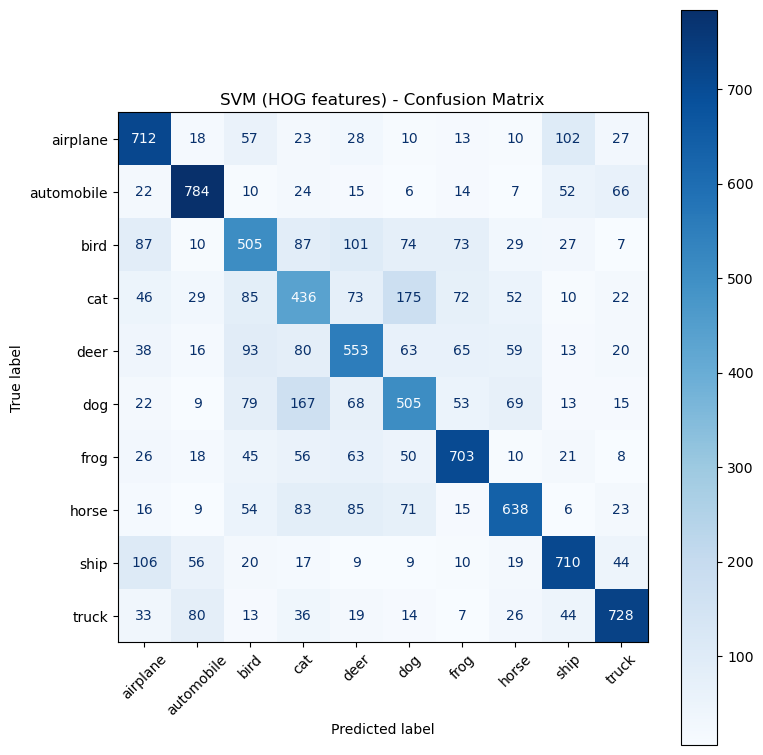

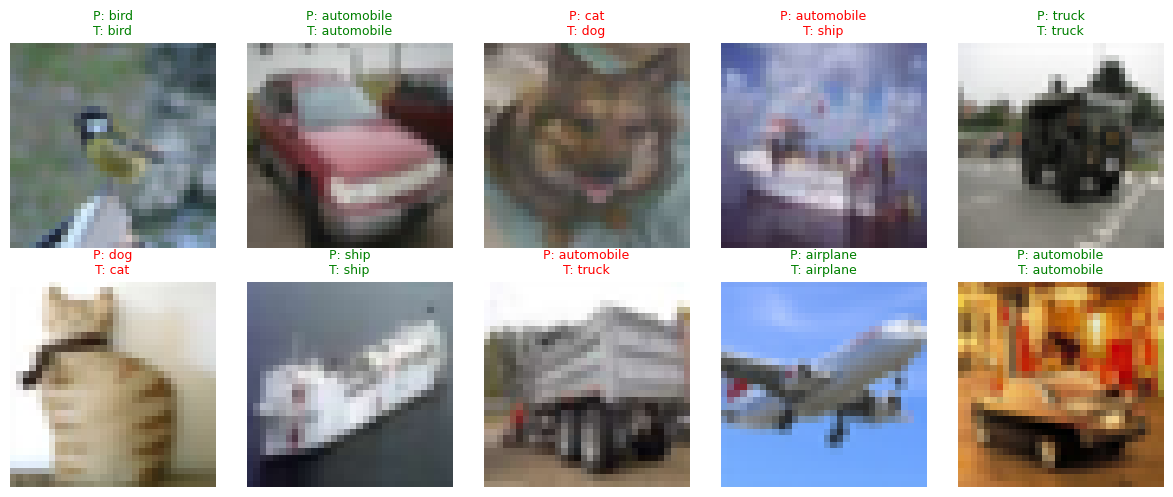

In [9]:
# Task 2: Machine Learning Model (SVM + HOG) on CIFAR-10

import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import os, pickle

np.random.seed(42)


# ## 1. Load the dataset (JUPYTER/NOTEBOOK VERSION)
# Set this manually depending on where your CIFAR-10 folder is located

DATA_DIR = "cifar-10-batches-py"   # <- change this if needed

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"CIFAR-10 folder not found at: {os.path.abspath(DATA_DIR)}\n"
        "Make sure 'cifar-10-batches-py' is in your notebook working directory."
    )


def load_batch(path):
    with open(path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')

    X = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y = np.array(d[b'labels'])
    return X, y


X_train_full = np.concatenate([
    load_batch(os.path.join(DATA_DIR, f"data_batch_{i}"))[0]
    for i in range(1, 6)
])

y_train_full = np.concatenate([
    load_batch(os.path.join(DATA_DIR, f"data_batch_{i}"))[1]
    for i in range(1, 6)
])

X_test, y_test = load_batch(os.path.join(DATA_DIR, "test_batch"))

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('Full train:', X_train_full.shape, ' Full test:', X_test.shape)


# ## 2. Data partitioning
# We first split the 50k training images into **two disjoint (non-overlapping)** parts so the
# tuning set never leaks into the final training set:
# - **tune subset** (10k) -> used only for GridSearchCV hyperparameter search.
# - **train subset** (up to 40k) -> used to fit the final model.

from sklearn.model_selection import train_test_split

N_TUNE = 10000     # held out only for hyperparameter search
N_TRAIN = 40000    # final-model training size (max = 50000 - N_TUNE = 40000)

# Step 1: carve a disjoint tune set out of the full training data (stratified)
X_train_sub, X_tune, y_train_sub, y_tune = train_test_split(
    X_train_full, y_train_full,
    test_size=N_TUNE, stratify=y_train_full, random_state=42)

# Step 2: take N_TRAIN images from the remaining pool for the final model (no overlap with tune)
if N_TRAIN >= len(X_train_sub):
    X_train, y_train = X_train_sub, y_train_sub          # use all 40k
else:
    X_train, _, y_train, _ = train_test_split(
        X_train_sub, y_train_sub,
        train_size=N_TRAIN, stratify=y_train_sub, random_state=42)

print('Tune:', X_tune.shape, ' Train:', X_train.shape, ' Test:', X_test.shape)


# ## 3. Feature extraction - HOG
# Convert each image to grayscale and compute its HOG descriptor (edges / shape / gradient orientation).
# This is the slowest non-training step for 30k+ images - expect a couple of minutes on Colab.


def extract_hog_features(images):
    feats = []
    for img in images:
        gray = rgb2gray(img)
        f = hog(gray,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

print('Extracting HOG features ...')
X_tune_hog = extract_hog_features(X_tune)
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)
print('HOG feature length:', X_train_hog.shape[1])


# ## 4a. Stage 1 - hyperparameter tuning on the 10k subset
# Search `C` and `gamma` with 3-fold cross-validation. Standardise features inside the pipeline.


pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

param_grid = {
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.001]
}

grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_tune_hog, y_tune)

print('Best params:', grid.best_params_)
print('Best CV accuracy (on tune subset):', grid.best_score_)

best_C = grid.best_params_['svc__C']
best_gamma = grid.best_params_['svc__gamma']


# ## 4b. Stage 2 - train the final model
# Refit a single SVM with the best params on the larger training set.


final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=best_C, gamma=best_gamma))
])

print(f'Training final SVM on {len(X_train)} images with C={best_C}, gamma={best_gamma} ...')
final_model.fit(X_train_hog, y_train)
print('Done.')


# ## 5. Performance assessment (on full 10k test set)

y_pred = final_model.predict(X_test_hog)

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}\n')
print(classification_report(y_test, y_pred, target_names=class_names))


# ### Overfitting check - compare train / CV / test accuracy
# A large gap between train and test accuracy indicates overfitting.

train_pred = final_model.predict(X_train_hog)
train_acc = accuracy_score(y_train, train_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"CV accuracy:    {grid.best_score_:.4f}")
print(f"Test accuracy:  {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('SVM (HOG features) - Confusion Matrix')
plt.tight_layout()
plt.show()


# ## 6. Show predictions on sample test images

n_show = 10
idx = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_test[i])
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'P: {class_names[y_pred[i]]}\nT: {class_names[y_test[i]]}', color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

